# 05 — Model Evaluation
**Tujuan:** Ukur dan analisis performa retrieval & prediksi.

Metrik:
- Accuracy, Precision, Recall, F1-Score
- Hit@1 / Hit@3 / Hit@5
- MRR (Mean Reciprocal Rank)
- Confusion matrix & bar chart perbandingan
- Error analysis (kasus gagal + rekomendasi)

```
projek-cbr-hukum/
└── data/
    ├── results/ ← input  (predictions.csv)
    └── eval/    ← output (metrik CSV + gambar PNG)
```

In [1]:
import re, json, pickle, ast, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.metrics.pairwise import cosine_similarity
warnings.filterwarnings('ignore')

BASE          = Path('..').resolve()
PROCESSED_DIR = BASE / 'data' / 'processed'
RESULTS_DIR   = BASE / 'data' / 'results'
EVAL_DIR      = BASE / 'data' / 'eval'
MODELS_DIR    = BASE / 'models'

df_pred = pd.read_csv(RESULTS_DIR / 'predictions.csv')
df      = pd.read_csv(PROCESSED_DIR / 'cases.csv')
df['text_combined'] = (
    df['ringkasan_fakta'].fillna('') + ' ' +
    df['pasal'].fillna('')            + ' ' +
    df['amar_putusan'].fillna('')
)

import pickle as pk
tfidf = pk.load(open(MODELS_DIR / 'tfidf_vectorizer.pkl', 'rb'))
svm   = pk.load(open(MODELS_DIR / 'svm_model.pkl',        'rb'))
nb    = pk.load(open(MODELS_DIR / 'nb_model.pkl',          'rb'))
le    = pk.load(open(MODELS_DIR / 'label_encoder.pkl',     'rb'))

df_f = df[df['label_vonis'].isin(le.classes_)].copy().reset_index(drop=True)

idx_test = pd.read_csv(EVAL_DIR / 'test_idx.csv')['idx'].tolist()
X_test   = df_f.loc[idx_test, 'text_combined'].tolist()
y_test   = le.transform(df_f.loc[idx_test, 'label_vonis'])

X_test_tfidf = tfidf.transform(X_test)

print(f'Predictions: {len(df_pred)} query')
print(f'Test set   : {len(X_test)} kasus')

Predictions: 15 query
Test set   : 12 kasus


In [2]:
# ════════════════════════════════════════════════════════════
# 1. METRIK PREDIKSI CBR
# ════════════════════════════════════════════════════════════
def calc_metrics(y_true, y_pred, name):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    }

# CBR (dari predictions.csv)
m_cbr_tf = calc_metrics(df_pred['expected_label'], df_pred['predicted_tfidf'], 'CBR TF-IDF')
m_cbr_bt = calc_metrics(df_pred['expected_label'], df_pred['predicted_bert'],  'CBR BERT')

# SVM langsung dari test set
svm_pred = svm.predict(X_test_tfidf)
m_svm    = calc_metrics(le.inverse_transform(y_test), le.inverse_transform(svm_pred), 'SVM (TF-IDF)')

# NB langsung dari test set
nb_pred = nb.predict(X_test_tfidf.toarray())
m_nb    = calc_metrics(le.inverse_transform(y_test), le.inverse_transform(nb_pred), 'Naive Bayes')

comparison = pd.DataFrame([m_cbr_tf, m_cbr_bt, m_svm, m_nb])
print('PERBANDINGAN MODEL')
print(comparison.to_string(index=False))

PERBANDINGAN MODEL
       Model  Accuracy  Precision  Recall  F1-Score
  CBR TF-IDF    0.6000     0.4061  0.6000    0.4819
    CBR BERT    0.4667     0.2667  0.4667    0.3394
SVM (TF-IDF)    0.6667     0.5455  0.6667    0.6000
 Naive Bayes    0.6667     0.6667  0.6667    0.6667


In [3]:
# ════════════════════════════════════════════════════════════
# 2. HIT@k & MRR  (dari query dengan true_case_id)
# ════════════════════════════════════════════════════════════
real_preds = df_pred[df_pred['query_id'].str.startswith('REAL_')].copy()

def hit_at_k(df_p, k):
    hits = 0
    for _, row in df_p.iterrows():
        ids  = ast.literal_eval(row['top_5_case_ids'])[:k]
        true = row['query_id'].replace('REAL_', '')
        if true in ids: hits += 1
    return hits / len(df_p) if len(df_p) else 0.0

def mrr_score(df_p):
    rr = []
    for _, row in df_p.iterrows():
        ids  = ast.literal_eval(row['top_5_case_ids'])
        true = row['query_id'].replace('REAL_', '')
        if true in ids:
            rr.append(1 / (ids.index(true) + 1))
        else:
            rr.append(0.0)
    return np.mean(rr) if rr else 0.0

if len(real_preds) > 0:
    print('RETRIEVAL METRICS (query dari data aktual)')
    print(f'  Hit@1 : {hit_at_k(real_preds, 1):.4f}')
    print(f'  Hit@3 : {hit_at_k(real_preds, 3):.4f}')
    print(f'  Hit@5 : {hit_at_k(real_preds, 5):.4f}')
    print(f'  MRR   : {mrr_score(real_preds):.4f}')
else:
    print('Tidak ada query real — Hit@k tidak dapat dihitung.')

RETRIEVAL METRICS (query dari data aktual)
  Hit@1 : 1.0000
  Hit@3 : 1.0000
  Hit@5 : 1.0000
  MRR   : 1.0000


In [4]:
# ════════════════════════════════════════════════════════════
# 3. CLASSIFICATION REPORT LENGKAP
# ════════════════════════════════════════════════════════════
print('=== CBR BERT — Classification Report ===')
print(classification_report(df_pred['expected_label'], df_pred['predicted_bert'], zero_division=0))

print('=== SVM — Classification Report ===')
print(classification_report(le.inverse_transform(y_test), le.inverse_transform(svm_pred), zero_division=0))

=== CBR BERT — Classification Report ===
                 precision    recall  f1-score   support

          bebas       0.00      0.00      0.00         2
          berat       0.00      0.00      0.00         1
         ringan       0.00      0.00      0.00         2
         sedang       0.00      0.00      0.00         2
tidak_diketahui       0.50      0.88      0.64         8

       accuracy                           0.47        15
      macro avg       0.10      0.17      0.13        15
   weighted avg       0.27      0.47      0.34        15

=== SVM — Classification Report ===
                 precision    recall  f1-score   support

          bebas       0.00      0.00      0.00         3
tidak_diketahui       0.73      0.89      0.80         9

       accuracy                           0.67        12
      macro avg       0.36      0.44      0.40        12
   weighted avg       0.55      0.67      0.60        12



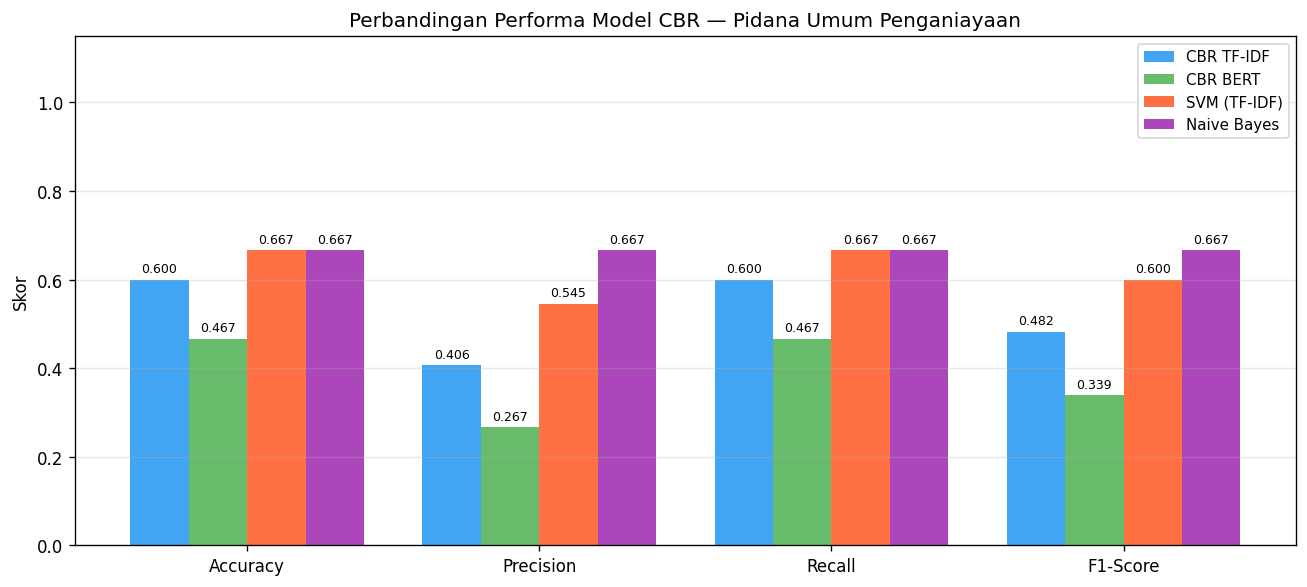

Grafik tersimpan → data/eval/model_comparison.png


In [5]:
# ════════════════════════════════════════════════════════════
# 4. BAR CHART PERBANDINGAN MODEL
# ════════════════════════════════════════════════════════════
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x        = np.arange(len(metrics))
width    = 0.20
colors   = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (_, row) in enumerate(comparison.iterrows()):
    offset = (i - len(comparison)/2 + 0.5) * width
    vals   = [row[m] for m in metrics]
    bars   = ax.bar(x + offset, vals, width, label=row['Model'],
                    color=colors[i % len(colors)], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Skor')
ax.set_title('Perbandingan Performa Model CBR — Pidana Umum Penganiayaan')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(EVAL_DIR / 'model_comparison.png', bbox_inches='tight')
plt.show()
print('Grafik tersimpan → data/eval/model_comparison.png')

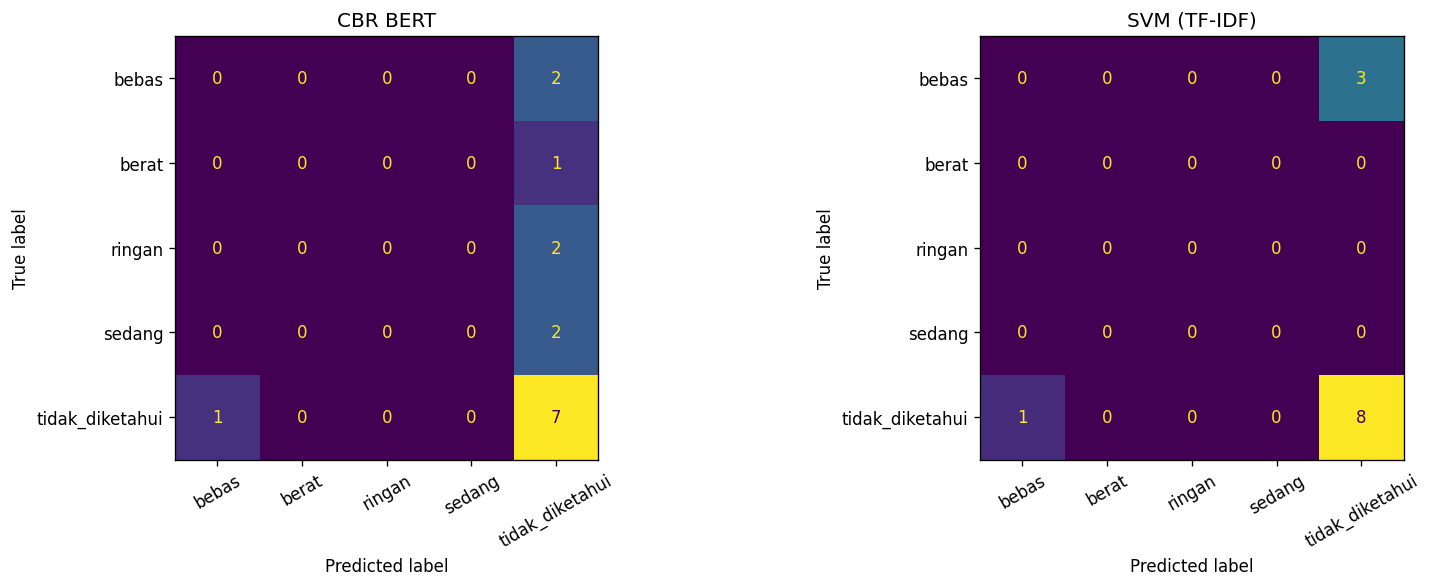

Confusion matrix tersimpan → data/eval/confusion_matrices.png


In [6]:
# ════════════════════════════════════════════════════════════
# 5. CONFUSION MATRIX
# ════════════════════════════════════════════════════════════
classes = sorted(df_pred['expected_label'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm1 = confusion_matrix(df_pred['expected_label'], df_pred['predicted_bert'], labels=classes)
ConfusionMatrixDisplay(cm1, display_labels=classes).plot(ax=axes[0], colorbar=False)
axes[0].set_title('CBR BERT')
axes[0].tick_params(axis='x', rotation=30)

cm2 = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(svm_pred), labels=classes)
ConfusionMatrixDisplay(cm2, display_labels=classes).plot(ax=axes[1], colorbar=False)
axes[1].set_title('SVM (TF-IDF)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(EVAL_DIR / 'confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Confusion matrix tersimpan → data/eval/confusion_matrices.png')

In [7]:
# ════════════════════════════════════════════════════════════
# 6. ERROR ANALYSIS (Rejection Analysis)
# ════════════════════════════════════════════════════════════
errors = df_pred[df_pred['predicted_bert'] != df_pred['expected_label']].copy()
total  = len(df_pred)

print(f'Kesalahan prediksi: {len(errors)}/{total} ({len(errors)/total:.1%})')

if len(errors) > 0:
    print('\n--- Pola Kesalahan ---')
    pola = errors.groupby(['expected_label','predicted_bert']).size() \
                 .reset_index(name='count').sort_values('count', ascending=False)
    print(pola.to_string(index=False))

    print('\n--- Contoh Kasus Gagal ---')
    for _, row in errors.head(3).iterrows():
        sims = ast.literal_eval(row['top_5_similarities'])
        print(f"  [{row['query_id']}] {row.get('description','')}")
        print(f"    Aktual: {row['expected_label']}  |  Prediksi: {row['predicted_bert']}")
        print(f"    Max similarity: {max(sims):.4f}")

print('\n--- Rekomendasi Perbaikan ---')
for i, rec in enumerate([
    'Tambah volume data penganiayaan (terutama kelas berat & bebas yang lebih jarang).',
    'Gunakan IndoBERT (indobenchmark/indobert-base-p1) untuk embedding Bahasa Indonesia lebih akurat.',
    'Perkuat ekstraksi Pasal 351-356 KUHP agar text_combined lebih diskriminatif.',
    'Terapkan threshold similarity minimum (mis. > 0.3) untuk menghindari noise retrieval.',
    'Class balancing dengan SMOTE/oversampling jika distribusi ringan/sedang/berat tidak merata.',
], 1):
    print(f'  {i}. {rec}')

errors.to_csv(EVAL_DIR / 'error_analysis.csv', index=False)
print('\nError analysis tersimpan → data/eval/error_analysis.csv')

Kesalahan prediksi: 8/15 (53.3%)

--- Pola Kesalahan ---
 expected_label  predicted_bert  count
          bebas tidak_diketahui      2
         ringan tidak_diketahui      2
         sedang tidak_diketahui      2
          berat tidak_diketahui      1
tidak_diketahui           bebas      1

--- Contoh Kasus Gagal ---
  [Q001] Penganiayaan ringan
    Aktual: ringan  |  Prediksi: tidak_diketahui
    Max similarity: 0.4522
  [Q002] Penganiayaan dengan senjata
    Aktual: sedang  |  Prediksi: tidak_diketahui
    Max similarity: 0.4087
  [Q003] Penganiayaan berujung kematian
    Aktual: berat  |  Prediksi: tidak_diketahui
    Max similarity: 0.5753

--- Rekomendasi Perbaikan ---
  1. Tambah volume data penganiayaan (terutama kelas berat & bebas yang lebih jarang).
  2. Gunakan IndoBERT (indobenchmark/indobert-base-p1) untuk embedding Bahasa Indonesia lebih akurat.
  3. Perkuat ekstraksi Pasal 351-356 KUHP agar text_combined lebih diskriminatif.
  4. Terapkan threshold similarity minimum (mi

In [8]:
# ════════════════════════════════════════════════════════════
# 7. SIMPAN SEMUA METRIK
# ════════════════════════════════════════════════════════════
comparison.to_csv(EVAL_DIR / 'retrieval_metrics.csv', index=False)

pred_metrics = pd.DataFrame([{
    'Model'    : 'CBR BERT (Weighted Vote)',
    'Accuracy' : m_cbr_bt['Accuracy'],
    'Precision': m_cbr_bt['Precision'],
    'Recall'   : m_cbr_bt['Recall'],
    'F1-Score' : m_cbr_bt['F1-Score'],
    'Hit@1'    : round(hit_at_k(real_preds, 1), 4) if len(real_preds) else 'N/A',
    'Hit@3'    : round(hit_at_k(real_preds, 3), 4) if len(real_preds) else 'N/A',
    'Hit@5'    : round(hit_at_k(real_preds, 5), 4) if len(real_preds) else 'N/A',
    'MRR'      : round(mrr_score(real_preds),   4) if len(real_preds) else 'N/A',
}])
pred_metrics.to_csv(EVAL_DIR / 'prediction_metrics.csv', index=False)

print(' Semua file evaluasi tersimpan:')
for f in ['retrieval_metrics.csv','prediction_metrics.csv',
          'error_analysis.csv','model_comparison.png','confusion_matrices.png']:
    print(f'   data/eval/{f}')

 Semua file evaluasi tersimpan:
   data/eval/retrieval_metrics.csv
   data/eval/prediction_metrics.csv
   data/eval/error_analysis.csv
   data/eval/model_comparison.png
   data/eval/confusion_matrices.png
